# OpenML Python API Examples (Sept 2026)
_Laith Agbaria and the OpenML Team_

This notebook is aimed at helping you start with OpenML through coding examples, teaching you the basics of using and contributing to the exchange of machine learning datasets, alogrithms, and evaluations. It is part of a larger tutorial which includes a guide and basic exercises, which can be found in [this GitHub repository](https://github.com/openml/openml-tutorial).

### Table of contents:
1. Introduction and imports
2. Datasets
3. Tasks
4. Runs and flows
5. Suites and studies
8. Community

---

## 1. Introduction
OpenML strives for open science, organizing the world's machine learning information to move data out of our labs and minds, and into online tools that help us organize and reuse it in unexpected new ways.

Through this tutorial you will gain experience in using OpenML to reduce the friction in the designing and selecting of machine learning algorithms (meta-learning), discovering and using shared datasets rich with meta-data, generating tool-independent descriptions of algorithms/pipelines, and linking objective evaluations of produced models to exact data and algorithms which are organized online. All details required for reproducability is automatically extracted with clean versioning of data and code, auto-tracking contributions to give credit where it's due.

This notebook is focused on utilizing the Python API (v1) and is intended to introduce you with the necessary basics, through which you will be able to conduct machine learning experiments and contribute to the scientific community.

### Requirements
This tutorial was made to run on Python 3.10+ with the following library versions:
- openml==0.15.1
- matplotlib==3.10.9
- seaborn==0.13.2
- notebook==7.6.2

In [ ]:
# Setting up

# Imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import openml

# Establishing a connection with a server
servers = {
    "main": "https://www.openml.org/api/v1/xml", 
    "local": "http://localhost:8000/api/v1/xml",  # Docker https://github.com/openml/services
    "test": "https://test.openml.org/api/v1/xml",
}
# openml.config.server = servers["main"]  # The main server is set by default

# Switching to test server can also be done with a function, here it is made into a wrapper
def test_server(code: callable, *args, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=UserWarning)  # Issues a UserWarning regarding server change
        openml.config.start_using_configuration_for_example()  # Enter test server state
        openml.config.apikey = "normaluser"  # Setting the API key (default None)
        try:
            return code(*args, **kwargs)  # Run your code
        finally:
            openml.config.stop_using_configuration_for_example()  # Go back to original state

# Quick check for current server
api_to_server = {v: k for k, v in servers.items()}
print(f"Currently on the {api_to_server[openml.config.server]} server.")

/home/laith/.cache/openml/org/openml/www
Currently on the real server.


#### Note regarding test server:
A test server is a clone of the real server that is intended to test functionalities and uses, being able to publish and modify without much worry over the consequences.

The API key changes to a default one temporarily when using this function, the given API key should be valid for the test server and is meant to reduce the friction when switching to testing.
Any existing API key will still be kept in memory and get restored when using the function: stop_using_configuration_for_example()

Future versions of openml should use the API key \"normaluser\" for the test server.

___
## 2. Datasets

In [ ]:
# Getting IDs and loading

columns = ["did", "name", "NumberOfInstances", "NumberOfFeatures", "NumberOfClasses"]
dataset_list = openml.datasets.list_datasets(output_format='dataframe', data_version=1, number_missing_values='0')  # Can add filters here
perfect_dataset_list = dataset_list.query("NumberOfInstances < 10000")[columns]
display(perfect_dataset_list.head(n=10))
display(dataset_list.query("name == 'iris'"))
openml.config.OPENML_SKIP_PARQUET_ENV_VAR

In [9]:
# Getting data

dataset = openml.datasets.get_dataset(dataset_id=61, download_data=True)  # Downloads a parquet file in ~/.cache/openml
target = dataset.default_target_attribute
X, y, categorical_indicator, attribute_names = dataset.get_data(target=target)  # Optional, separate y by selecting target='<column>'
display(X.head())

,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


> Datasets contain the following attributes: {'ignore_attribute': None, 'dataset_id': 61, 'name': 'iris', 'version': 1, 'description': "**Author**: R.A. Fisher  \n**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Iris) - 1936 - Donated by Michael Marshall  \n**Please cite**:   \n\n**Iris Plants Database**  \nThis is perhaps the best known database to be found in the pattern recognition literature.  Fisher's paper is a classic in the field and is referenced frequently to this day.  (See Duda & Hart, for example.)  The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.  One class is     linearly separable from the other 2; the latter are NOT linearly separable from each other.\n\nPredicted attribute: class of iris plant.  \nThis is an exceedingly simple domain.  \n \n### Attribute Information:\n    1. sepal length in cm\n    2. sepal width in cm\n    3. petal length in cm\n    4. petal width in cm\n    5. class: \n       -- Iris Set

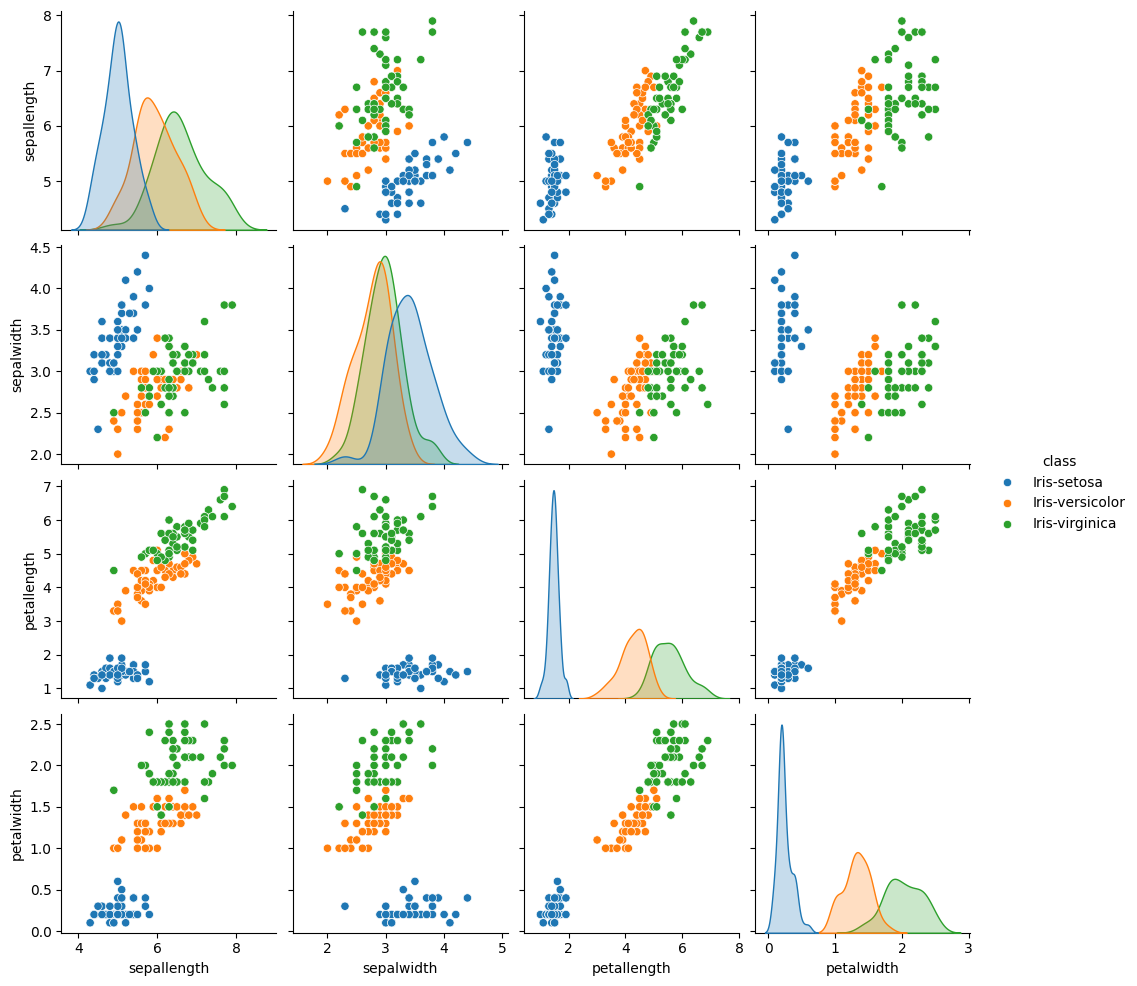

In [10]:
# Exploring and plotting

print(f"> Datasets contain the following attributes: {vars(dataset)}\n")
print(f"> This dataset is '{dataset.name}', the target feature is '{target}'\n")
print(f"> URL: {dataset.url}\n")
print(f"> Description:\n{dataset.description}")
# Data can be plotted normally as it is a DataFrame
plot = sns.pairplot(pd.concat([X, y], axis=1), hue=target)
plt.show()

In [11]:
# Alternative finding of dataset through sklearn

from sklearn.datasets import fetch_openml  # Gets from the main https://www.openml.org server
dataset = fetch_openml(name='eeg-eye-state', version=1)  # Can use dataset ID as well
X, y = dataset.data, dataset.target
print(dataset.details)
display(X)

{'id': '1471', 'name': 'eeg-eye-state', 'version': '1', 'description_version': '1', 'format': 'ARFF', 'upload_date': '2015-05-22T16:40:04', 'licence': 'Public', 'url': 'https://openml.org/data/v1/download/1587924/eeg-eye-state.arff', 'parquet_url': 'https://data.openml.org/datasets/0000/1471/dataset_1471.pq', 'file_id': '1587924', 'default_target_attribute': 'Class', 'tag': ['brain', 'Data Science', 'EEG', 'Kaggle', 'Neuroscience', 'OpenML100', 'Psychology', 'study_123', 'study_14', 'study_34', 'study_7', 'time_series', 'uci'], 'visibility': 'public', 'status': 'active', 'processing_date': '2019-07-09 15:20:53', 'md5_checksum': '32086b7bec4daaa9cbe5f19efa63368c'}


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77


In [ ]:
# Additional dataset plotting example

dataset = openml.datasets.get_dataset("eeg-eye-state", version=1)  # Can use the dataset name instead of ID
target = dataset.default_target_attribute
X, y, categorical_indicator, attribute_names = dataset.get_data(target=target)

# Sequential data
X.plot(logy=True,ylim=(3900,5000),figsize=(20, 10))
plt.show()
# Target
y.astype(int).plot(figsize=(20, 1))
plt.show()

### Publishing datasets and more

A dataset can be prepared in many ways, but it must be published so that it can be used in its full capacity.

In [ ]:
from openml.datasets.functions import create_dataset, delete_dataset, edit_dataset

# Publish any OpenML object
def publish(oml_obj):
    oml_obj.publish()
    print(f"Published to URL: {oml_obj.openml_url}")

In [ ]:
# Lists to OpenML (Run this one)

data = [
    ["sunny", 85, 85, "FALSE", "no"],
    ["sunny", 80, 90, "TRUE", "no"],
    ["overcast", 83, 86, "FALSE", "yes"],
    ["rainy", 70, 96, "FALSE", "yes"],
    ["rainy", 68, 80, "FALSE", "yes"],
    ["rainy", 65, 70, "TRUE", "no"],
    ["overcast", 64, 65, "TRUE", "yes"],
    ["sunny", 72, 95, "FALSE", "no"],
    ["sunny", 69, 70, "FALSE", "yes"],
    ["rainy", 75, 80, "FALSE", "yes"],
    ["sunny", 75, 70, "TRUE", "yes"],
    ["overcast", 72, 90, "TRUE", "yes"],
    ["overcast", 81, 75, "FALSE", "yes"],
    ["rainy", 71, 91, "TRUE", "no"],
]

attribute_names = [
    ("outlook", ["sunny", "overcast", "rainy"]),
    ("temperature", "REAL"),
    ("humidity", "REAL"),
    ("windy", ["TRUE", "FALSE"]),
    ("play", ["yes", "no"]),
]

description = (
    "The weather problem is a tiny dataset that we will use repeatedly"
    " to illustrate machine learning methods. Entirely fictitious, it "
    "supposedly concerns the conditions that are suitable for playing "
    "some unspecified game. In general, instances in a dataset are "
    "characterized by the values of features, or attributes, that measure "
    "different aspects of the instance. In this case there are four "
    "attributes: outlook, temperature, humidity, and windy. "
    "The outcome is whether to play or not."
)

citation = (
    "I. H. Witten, E. Frank, M. A. Hall, and ITPro,"
    "Data mining practical machine learning tools and techniques, "
    "third edition. Burlington, Mass.: Morgan Kaufmann Publishers, 2011"
)

weather_dataset = create_dataset(
    # The name of the dataset (Should be unique).
    # Must not be longer than 128 characters and only contain
    # a-z, A-Z, 0-9 and the following special characters: _\-\.(),
    name="Weather_tutorial",
    # Textual description of the dataset.
    description=description,
    # The person who created the dataset.
    creator="I. H. Witten, E. Frank, M. A. Hall, and ITPro",
    # People who contributed to the current version of the dataset.
    contributor=None,
    # The date the data was originally collected, given by the uploader.
    collection_date="01-01-2011",
    # Language in which the data is represented.
    # Starts with 1 upper case letter, rest lower case, e.g. 'English'.
    language="English",
    # License under which the data is/will be distributed.
    licence=None,
    # Name of the target. Can also have multiple values (comma-separated).
    default_target_attribute="play",
    # The attribute that represents the row-id column, if present in the dataset.
    row_id_attribute=None,
    # Attribute or list of attributes that should be excluded in modelling, such as
    # identifiers and indexes. E.g. "feat1" or ["feat1","feat2"]
    ignore_attribute=None,
    # How to cite the paper.
    citation=citation,
    # A version label which is provided by the user.
    version_label="test",
    # Original source of the data.
    original_data_url=None,
    # Attributes of the data
    attributes=attribute_names,
    data=data,
    
)

# Publishing to the test server normally
openml.config.start_using_configuration_for_example()  # Enter test server state
openml.config.apikey = "normaluser"  # Set a working API key
weather_dataset.publish()  # Publish dataset, the only line of code you actually need to publish to current server
print(f"URL for dataset: {weather_dataset.openml_url}")  # Look up where it was published
openml.config.stop_using_configuration_for_example()  # Exit test server state

In [ ]:
# You can use a pandas DataFrame instead

df = pd.DataFrame(data, columns=[col_name for col_name, _ in attribute_names])

# Enforce the categorical column to have a categorical dtype
df["outlook"] = df["outlook"].astype("category")
df["windy"] = df["windy"].astype("bool")
df["play"] = df["play"].astype("category")

weather_dataset_df = create_dataset(
    name="Weather_tutorial",
    description=description,
    creator="I. H. Witten, E. Frank, M. A. Hall, and ITPro",
    contributor=None,
    collection_date="01-01-2011",
    language="English",
    licence=None,
    default_target_attribute="play",
    ignore_attribute=None,
    citation=citation,
    # CHANGED HERE!
    attributes="auto",
    data=df,
)

# test_server(publish, weather_dataset_df)

In [ ]:
# Or a sparse matrix

def matrix_example():
    from scipy.sparse import coo_matrix

    sparse_data = coo_matrix(
        ([0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], ([0, 1, 1, 2, 2, 3, 3], [0, 1, 2, 0, 2, 0, 1]))
    )

    column_names = [
        ("input1", "REAL"),
        ("input2", "REAL"),
        ("y", "REAL"),
    ]

    xor_dataset = create_dataset(
        name="XOR_tutorial",
        description="Dataset representing the XOR operation",
        creator=None,
        contributor=None,
        collection_date=None,
        language="English",
        licence=None,
        default_target_attribute="y",
        row_id_attribute=None,
        ignore_attribute=None,
        citation=None,
        attributes=column_names,
        data=sparse_data,
        version_label="1",
    )
    
    xor_dataset.publish()
    print(f"URL for dataset: {xor_dataset.openml_url}")
    return xor_dataset

# xor_dataset = test_server(matrix_example)

In [ ]:
# And even ARFF files

def arff_example():
    import urllib.request
    
    urllib.request.urlretrieve("https://openml.org/data/v1/download/61/iris.arff", "dataset.arff")
    iris_dataset = openml.datasets.OpenMLDataset(data_file='dataset.arff', 
                                                 name='iris_tutorial', 
                                                 description='Test dataset', 
                                                 licence='Public', 
                                                 default_target_attribute='class')
    iris_dataset.publish()
    print(f"URL for dataset: {iris_dataset.openml_url}")
    return iris_dataset

# iris_dataset = test_server(arff_example)

In [ ]:
# From sklearn to OpenML

def sklearn_diabtes_example():
    from sklearn.datasets import load_diabetes

    diabetes = load_diabetes()
    name = "Diabetes_sklearn_tutorial"
    X = diabetes.data
    y = diabetes.target
    attribute_names = diabetes.feature_names
    description = diabetes.DESCR

    data = np.concatenate((X, y.reshape((-1, 1))), axis=1)
    attribute_names = list(attribute_names)
    attributes = [(attribute_name, "REAL") for attribute_name in attribute_names] + [
        ("class", "INTEGER")
    ]
    citation = (
        "Bradley Efron, Trevor Hastie, Iain Johnstone and "
        "Robert Tibshirani (2004) (Least Angle Regression) "
        "Annals of Statistics (with discussion), 407-499"
    )
    paper_url = "https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf"

    diabetes_dataset = create_dataset(
        name=name,
        description=description,
        creator="Bradley Efron, Trevor Hastie, Iain Johnstone and Robert Tibshirani",
        contributor=None,
        collection_date="09-01-2012",
        language="English",
        licence="BSD (from scikit-learn)",
        default_target_attribute="class",
        row_id_attribute=None,
        ignore_attribute=None,
        citation=citation,
        attributes=attributes,
        data=data,
        version_label="test",
        original_data_url="https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html",
        paper_url=paper_url,
    )

    diabetes_dataset.publish()
    print(f"URL for dataset: {diabetes_dataset.openml_url}")
    return diabetes_dataset

# diabetes_dataset = test_server(sklearn_diabtes_example)

In [ ]:
# You can also fork and edit datasets you own

def fork_example(dataset):
    # Create a fork
    try:
        fork_id = openml.datasets.fork_dataset(dataset.id)  # Increases the version counter and returns the dataset ID
        print(f"Forked dataset {dataset.id} and got dataset {fork_id}, it has the version {openml.datasets.get_dataset(fork_id).version}")
    except openml.exceptions.OpenMLServerException as err:
        # It doesn't exist
        print(err.message)
    except openml.exceptions.OpenMLNotAuthorizedError as err:
        # You don't own it or it is being used by a task
        print(err.message)

    # Edit the fork
    try:
        edit_dataset(fork_id, description=f"THIS IS EDITED!\n\n{dataset.description}")  # Non-critical fields, returns the ID
        print(f"You can check the modified description on https://test.openml.org/d/{fork_id}")
    except openml.exceptions.OpenMLServerException as err:
        # It doesn't exist
        print(err.message)
    except openml.exceptions.OpenMLNotAuthorizedError as err:
        # You don't own it or it is being used by a task
        print(err.message)
    return fork_id

fork_id = test_server(fork_example, weather_dataset)

In [ ]:
# Or delete datasets you own that are free from tasks

def delete_example(did):
    try:
        delete_dataset(did)
        print(f"Successfully deleted dataset.")
    except openml.exceptions.OpenMLServerException as err:
        # It doesn't exist
        print(err.message)
    except openml.exceptions.OpenMLNotAuthorizedError as err:
        # You don't own it or it is being used by a task
        print(err.message)
    print(f"Dataset ID: {did}.\n")

test_server(delete_example, fork_id)

___
## 3. Tasks

In [ ]:
# Finding tasks

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=RuntimeWarning)
    # Might produce runtime warnings for tasks that can't be created
    task_list = openml.tasks.list_tasks(output_format='dataframe')
    
columns = ["tid", "name", "task_type", "target_feature", "NumberOfInstances", "NumberOfFeatures", "NumberOfClasses"]
display(task_list[columns].head(n=10))
filtered_list = task_list.query("name == 'pendigits'")
display(filtered_list.iloc[:1])

In [ ]:
# Loading tasks

task = openml.tasks.get_task(32)  # Must be by ID
print(task)

# Extracting datasets
dataset = task.get_dataset()
print(dataset)
# print(dataset.description[:500])
X, y = task.get_X_and_y(dataset_format="dataframe")
display(X.head(), y.head())


In [ ]:
# Data splitting, some tasks might cause a crash

repeats, folds, samples = task.get_split_dimensions()
print(f"Repeats: {repeats}, folds: {folds}, samples: {samples}")
train_indices, test_indices = task.get_train_test_split_indices(fold=folds-1)
display(X.iloc[train_indices])

In [ ]:
# Using the dataset in the task

tid = 61  # 10 repeats of 10-fold Crossvalidation with 9 samples
task = openml.tasks.get_task(tid)
X, y = task.get_X_and_y(dataset_format="dataframe")
n_repeats, n_folds, n_samples = task.get_split_dimensions()
for repeat_idx in range(n_repeats):
    for fold_idx in range(n_folds):
        for sample_idx in range(n_samples):
            train_indices, test_indices = task.get_train_test_split_indices(
                repeat=repeat_idx,
                fold=fold_idx,
                sample=sample_idx,
            )
            X_train = X.iloc[train_indices]
            y_train = y.iloc[train_indices]
            X_test = X.iloc[test_indices]
            y_test = y.iloc[test_indices]

            # You can add training/evaluation code here, OpenML flows...
            if repeat_idx == fold_idx == sample_idx:  # No need to flood the screen
                print(
                    f"Repeat #{repeat_idx}, fold #{fold_idx}, samples {sample_idx}: X_train.shape: {X_train.shape}, "
                    f"y_train.shape {y_train.shape}, X_test.shape {X_test.shape}, y_test.shape {y_test.shape}"
                )

In [ ]:
# print(f"Currently on the {api_to_server[openml.config.server]} server.")
from openml.tasks import TaskType
test_task = openml.tasks.create_task(task_type=TaskType.SUPERVISED_CLASSIFICATION, dataset_id=1, estimation_procedure_id=5)
print(test_task.estimation_procedure)

___
## 4. Runs and flows

In [ ]:
# Flows

import sklearn
from sklearn.neighbors import KNeighborsClassifier


openml.config.start_using_configuration_for_example()
task = openml.tasks.get_task(119)
X, y = task.get_X_and_y(dataset_format="dataframe")
train_indices, test_indices = task.get_train_test_split_indices()
X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

knn_parameters = {
    "n_neighbors": 3,
}
clf = KNeighborsClassifier(**knn_parameters)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

sum(y_pred == y_test) / len(y_test)

In [ ]:
knn_flow = openml.flows.OpenMLFlow(
    # Metadata
    model=clf,  # or None, if you do not want to upload the model object.
    name="CustomKNeighborsClassifier",
    description="A custom KNeighborsClassifier flow for OpenML.",
    external_version=f"{sklearn.__version__}",
    language="English",
    tags=["openml_tutorial_knn"],
    dependencies=f"{sklearn.__version__}",
    # Hyperparameters
    parameters={k: str(v) for k, v in knn_parameters.items()},
    parameters_meta_info={
        "n_neighbors": {"description": "number of neighbors to use", "data_type": "int"}
    },
    # If you have a pipeline with subcomponents, such as preprocessing, add them here.
    components={},
)

In [ ]:
predictions = []
for test_index, y_true_i, y_pred_i, y_pred_proba_i in zip(
    test_indices, y_test, y_pred, y_pred_proba, strict=False
):
    predictions.append(
        openml.runs.functions.format_prediction(
            task=task,
            repeat=0,
            fold=0,
            index=test_index,
            prediction=y_pred_i,
            truth=y_true_i,
            proba=dict(zip(task.class_labels, y_pred_proba_i, strict=False)),
        )
    )

# Format the parameters for OpenML
oml_knn_parameters = [
    {"oml:name": k, "oml:value": v, "oml:component": knn_flow.flow_id}
    for k, v in knn_parameters.items()
]

knn_run = openml.runs.OpenMLRun(
    task_id=task.task_id,
    flow_id=knn_flow.flow_id,
    dataset_id=dataset.dataset_id,
    parameter_settings=oml_knn_parameters,
    data_content=predictions,
    tags=["openml_tutorial_knn"],
    description_text="Run generated by the tutorial.",
)

print(knn_run)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# This requires an API key!
run, flow = openml.runs.run_model_on_task(model=DecisionTreeClassifier(), task=119, return_flow=True)
print(run)
print(128*'='+'\n'+128*'=')
print(flow)
openml.config.stop_using_configuration_for_example()

In [ ]:
from openml.tasks import TaskType

evals = openml.evaluations.list_evaluations(function='area_under_roc_curve', 
                                            tasks=openml.tasks.list_tasks(TaskType.SUPERVISED_CLASSIFICATION,  # Could also just be tasks=[37]
                                                                          data_id=openml.datasets.get_dataset("diabetes").id),
                                            size=1000)
scores = sorted([{"flow":e.flow_name[-25:], "score":e.value} for id, e in evals.items()], key=lambda x: -x["score"])[:50]
plt.figure(figsize=(8, 16))
sns.violinplot(x="score", y="flow", data=pd.DataFrame(scores), density_norm='width', cut=0, palette="Set3", hue="flow")

___
## 5. Suites and studies

(Under construction...)

In [1]:
import openml
import logging
from flaml import AutoML

logging.getLogger("flaml").setLevel(logging.CRITICAL)

for task_id in openml.study.get_suite(99).tasks[:5]:
    try:
        task = openml.tasks.get_task(task_id)
        X, y = task.get_X_and_y(dataset_format="dataframe")
        train_indices, test_indices = task.get_train_test_split_indices()
        X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
        y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
        automl = AutoML(time_budget=8, verbose=1)
        automl.fit(X_train, y_train)

        y_pred = automl.predict(X_test)
        y_pred_proba = automl.predict_proba(X_test)

        print(f"Final performance on task {task.id}:", sum(y_pred == y_test) / len(y_test))
    except:
        print(f"Error during {task.id}")
print("Complete.")

Final performance on task 3: 1.0
Final performance on task 6: 0.962
Final performance on task 11: 0.9523809523809523
Final performance on task 12: 0.97
Final performance on task 14: 0.855
Complete.


In [ ]:
# Benchmarks

suite = openml.study.get_suite(99)  # ID or alias
for task_id in suite.tasks:
    try:
        task = openml.tasks.get_task(task_id)
    except:
        print(task.id)
suite

___
## 6. Community

You have reached the end of the practical examples, and we hope that it has succesfully provided a sufficient introduction to OpenML.
OpenML is built with community contributions, and now you are able to be part of that community :)